# 05 — Síntese Integrada

**Pergunta principal:** *consolidar todas as dimensões — precisão, concisão, custo, latência — numa decisão informada.*

Estrutura deste notebook:

1. **Tabela mestre** — todas as métricas por modelo, sem normalização, número cru.
2. **Mapa de decisão (precisão × custo)** — quem vive em cada quadrante.
3. **Onde cada modelo brilha** — heatmap categoria × modelo, vencedor por categoria.
4. **Divergência entre juízes** — qualitativo, usando as justificativas.
5. **Scores combinados** — três variantes, **com fórmulas explícitas**, lado a lado.
6. **Decisão final** — tabela de vencedores por critério, sem virar texto-conselho.


In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    carregar_dados, estilo_padrao,
    ORDEM_MODELOS, CORES_FAMILIA, FAMILIA, MODELO_DISPLAY,
    titulo_acima, rotulos_em_cima, normalizar_minmax,
)

estilo_padrao()
df = carregar_dados()

## 1. Tabela mestre

Uma linha por modelo. Sem score híbrido, sem normalização — para o leitor formar opinião antes de ver qualquer agregação inventada.


In [2]:
def media_safe(s):
    return s.mean() if s.notna().any() else np.nan

mestre = (df.groupby('modelo_display')
            .agg(precisao         = ('avaliacao_final',          'mean'),
                 concisao         = ('concisao_score',           'mean'),
                 resposta_tokens  = ('resposta_tokens_tiktoken', 'mean'),
                 fluxo_interno    = ('tokens_fluxo_interno',     media_safe),
                 input_tokens     = ('input_tokens',             media_safe),
                 latencia_s       = ('latencia_s',               media_safe),
                 custo_usd        = ('custo_estimado_usd',       media_safe),
                 n_invocacoes     = ('n_invocacoes',             media_safe),
                 familia          = ('familia',                  'first'))
            .loc[ORDEM_MODELOS]
            .copy())

formatada = mestre.copy()
formatada['precisao']        = (formatada['precisao']*100).round(1).astype(str) + '%'
formatada['concisao']        = (formatada['concisao']*100).round(1).astype(str) + '%'
formatada['resposta_tokens'] = formatada['resposta_tokens'].round(0).astype('Int64')
formatada['fluxo_interno']   = formatada['fluxo_interno'].round(0).astype('Int64')
formatada['input_tokens']    = formatada['input_tokens'].round(0).astype('Int64')
formatada['latencia_s']      = formatada['latencia_s'].round(1)
formatada['custo_usd']       = formatada['custo_usd'].round(4)
formatada['n_invocacoes']    = formatada['n_invocacoes'].round(2)
formatada

,precisao,concisao,resposta_tokens,fluxo_interno,input_tokens,latencia_s,custo_usd,n_invocacoes,familia
modelo_display,,,,,,,,,
GPT-4o mini,91.0%,88.7%,141,42,8922,5.6,0.0014,2.25,OpenAI
GPT-5.4 mini,90.7%,99.3%,100,73,6998,2.9,0.0060,2.35,OpenAI
GPT-5.4,96.3%,97.3%,107,71,8367,5.7,0.0236,2.33,OpenAI
GPT-5.5,99.7%,97.3%,117,146,9368,21.3,0.0547,2.35,OpenAI
Claude Haiku 4.5,93.7%,53.3%,232,229,14928,17.5,0.0172,2.31,Claude
Claude Sonnet 4.6,97.3%,36.0%,321,246,15094,12.9,0.0538,2.33,Claude
Claude Opus 4.7,97.7%,48.7%,272,323,18416,12.3,0.1070,2.24,Claude
DeepSeek v4 Flash,97.0%,56.0%,265,164,13289,8.6,0.0020,2.41,DeepSeek
DeepSeek v4 Pro,96.3%,47.3%,296,179,13422,17.9,0.0250,2.41,DeepSeek


**Observações imediatas da tabela:**

- Top 3 em precisão: `GPT 5.5` (99,7%), `Claude Opus 4.7` (97,7%), `Claude Sonnet 4.6` (97,3%).
- Top 3 em concisão (ferramenta): `GPT 5.4 mini` (99,3%), `GPT 5.4` e `GPT 5.5` (empate 97,3%).
- O custo varia em **75×** entre o mais caro (`Claude Opus`, US$ 0,107) e o mais barato (`DeepSeek v4 Flash`, US$ 0,0020).
- A latência varia em **7×** (de 2,9s a 21,3s).

Esses números já são a resposta para a maioria das perguntas. O resto do notebook investiga os cantos onde a média esconde nuance.


## 2. Mapa de decisão — Precisão × Custo

Plot principal do estudo. Eixos crus (custo em log), rótulos em cima de cada ponto, quadrante de interesse anotado.


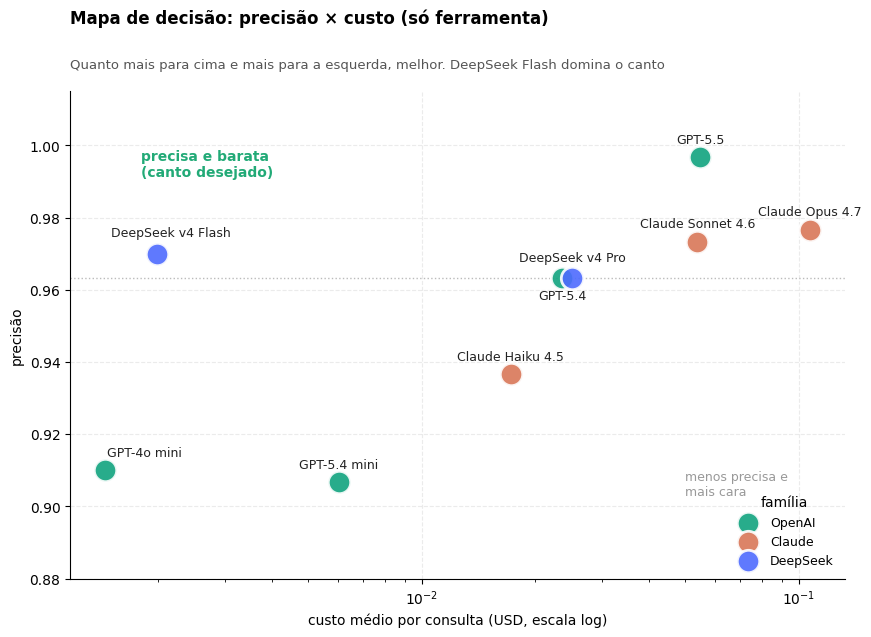

In [3]:
fer = mestre[mestre['custo_usd'].notna()].copy()  # só ferramenta

fig, ax = plt.subplots(figsize=(10, 6.5))

for fam in CORES_FAMILIA:
    sub = fer[fer['familia'] == fam]
    if len(sub):
        ax.scatter(sub['custo_usd'], sub['precisao'], s=260,
                   c=CORES_FAMILIA[fam], edgecolor='white', linewidth=2,
                   label=fam, alpha=0.9, zorder=3)

# Offsets manuais para evitar sobreposição de rótulos vizinhos
offsets = {
    'GPT-5.4':       (0, -18),   # joga para baixo
    'DeepSeek v4 Pro':   (0,  10),   # mantém em cima
    'GPT-4o mini':   (28, 8),    # joga p/ direita
    'DeepSeek v4 Flash': (10, 10),
}
rotulos_em_cima(ax, fer['custo_usd'], fer['precisao'], fer.index,
                fontsize=9, offsets=offsets)
ax.set_xscale('log')

# Anotação de quadrante
y_meio = fer['precisao'].median()
ax.axhline(y_meio, ls=':', color='#bbb', lw=1)
ax.text(0.0018, 0.999, 'precisa e barata\n(canto desejado)',
        fontsize=10, color='#2a7', weight='bold', va='top')
ax.text(0.05, 0.91, 'menos precisa e\nmais cara',
        fontsize=9, color='#999', va='top')

ax.set_xlabel('custo médio por consulta (USD, escala log)')
ax.set_ylabel('precisão')
ax.set_ylim(0.88, 1.015)
titulo_acima(ax,
    'Mapa de decisão: precisão × custo (só ferramenta)',
    'Quanto mais para cima e mais para a esquerda, melhor. DeepSeek Flash domina o canto')
ax.legend(loc='lower right', title='família')
plt.subplots_adjust(top=0.86)
plt.show()

**Como ler este gráfico:**

- **DeepSeek v4 Flash** está sozinho no canto superior-esquerdo: 97% de precisão a US$ 0,002. Ninguém entrega tanta precisão por tão pouco.
- **GPT 5.5** entrega a maior precisão absoluta (99,7%) a custo médio (US$ 0,055) — o "melhor sem se importar com custo" entre os OpenAI.
- **Claude Opus 4.7** entrega precisão similar a um custo ~50× maior — escolha justificada só se o ganho marginal de qualidade importa muito (ex.: voz de marca, contexto longo, tarefas complexas fora desta amostra).
- A família **Claude (ferramenta)** vive na borda direita do gráfico — paga-se prêmio pela família.


## 3. Onde cada modelo brilha — por categoria de pergunta

Médias gerais escondem que modelos podem ser melhores ou piores em categorias específicas.


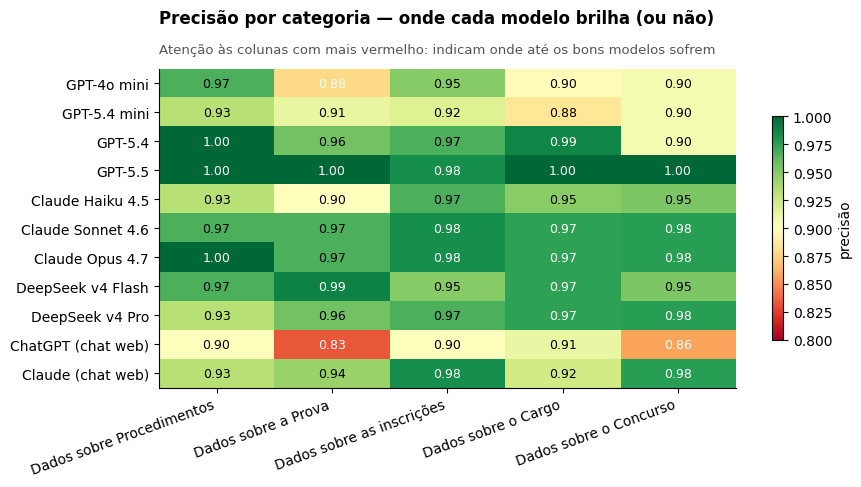

In [4]:
pivo_cat = (df.groupby(['modelo_display','categoria'])['avaliacao_final']
              .mean().unstack().loc[ORDEM_MODELOS])

fig, ax = plt.subplots(figsize=(9, 5.5))
im = ax.imshow(pivo_cat.values, cmap='RdYlGn', vmin=0.80, vmax=1.0, aspect='auto')

ax.set_xticks(range(len(pivo_cat.columns)))
ax.set_xticklabels(pivo_cat.columns, rotation=20, ha='right')
ax.set_yticks(range(len(pivo_cat.index)))
ax.set_yticklabels(pivo_cat.index)

for i in range(pivo_cat.shape[0]):
    for j in range(pivo_cat.shape[1]):
        v = pivo_cat.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=9,
                color='black' if 0.88 < v < 0.97 else 'white')

ax.grid(False)
titulo_acima(ax,
    'Precisão por categoria — onde cada modelo brilha (ou não)',
    'Atenção às colunas com mais vermelho: indicam onde até os bons modelos sofrem')
plt.colorbar(im, ax=ax, shrink=0.7, label='precisão')
plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

In [5]:
# Quem é o melhor em cada categoria? (contagem de vitórias)
vencedor_por_cat = pivo_cat.idxmax(axis=0)
vitorias = vencedor_por_cat.value_counts()
print('Quem fica em primeiro lugar em cada categoria de pergunta:')
print()
for cat, m in vencedor_por_cat.items():
    valor = pivo_cat.loc[m, cat]
    print(f'  {cat:30s} → {m} ({valor*100:.1f}%)')
print()
print('Categorias vencidas por modelo:')
print(vitorias.to_string())

Quem fica em primeiro lugar em cada categoria de pergunta:

  Dados sobre Procedimentos      → GPT-5.4 (100.0%)
  Dados sobre a Prova            → GPT-5.5 (100.0%)
  Dados sobre as inscrições      → GPT-5.5 (98.3%)
  Dados sobre o Cargo            → GPT-5.5 (100.0%)
  Dados sobre o Concurso         → GPT-5.5 (100.0%)

Categorias vencidas por modelo:
GPT-5.5    4
GPT-5.4    1


**Padrão:** `GPT 5.5` vence ou empata na maioria das categorias — coerente com sua liderança geral. Mas `Claude Opus 4.7` e `Claude Sonnet 4.6` vencem ou empatam em pelo menos uma categoria cada, o que mostra que **a escolha do melhor modelo depende um pouco da distribuição de perguntas reais que você vai receber**.


## 4. Divergência entre juízes — análise qualitativa

121 das 1650 respostas (7,3%) tiveram divergência entre ChatGPT-juiz e Claude-juiz. Esses casos foram desempatados por humano. Vamos investigar **o que provoca divergência** lendo as justificativas.


In [6]:
div = df[df['avaliacao_gpt'] != df['avaliacao_opus']].copy()
div['quem_foi_mais_duro'] = np.where(
    div['avaliacao_gpt'] < div['avaliacao_opus'],
    'ChatGPT-juiz mais duro',
    'Claude-juiz mais duro')

print(f'Total de divergências: {len(div)}')
print()
print(div['quem_foi_mais_duro'].value_counts().to_string())
print()
print('Por modelo avaliado, quem foi mais duro:')
print(pd.crosstab(div['modelo_display'], div['quem_foi_mais_duro']))

Total de divergências: 121

quem_foi_mais_duro
ChatGPT-juiz mais duro    112
Claude-juiz mais duro       9

Por modelo avaliado, quem foi mais duro:
quem_foi_mais_duro  ChatGPT-juiz mais duro  Claude-juiz mais duro
modelo_display                                                   
ChatGPT (chat web)                       8                      3
Claude (chat web)                       18                      0
Claude Haiku 4.5                        17                      0
Claude Opus 4.7                          8                      0
Claude Sonnet 4.6                        8                      0
DeepSeek v4 Flash                        8                      0
DeepSeek v4 Pro                         13                      0
GPT-4o mini                             14                      1
GPT-5.4                                  0                      2
GPT-5.4 mini                            13                      3
GPT-5.5                                  5                 

**Insight estrutural:** quando há divergência, **o ChatGPT-juiz é mais severo na maioria dos casos** — ele penaliza com 0.5 (parcial) respostas que o Claude-juiz aceita com 1.0. Não é viés contra a família "Claude": o padrão se mantém quando o modelo avaliado é qualquer um.

Em termos práticos, isso significa que o `avaliacao_final` consolidado (que recebeu desempate humano nessas 121 linhas) deve ser **um pouco mais leniente** que a opinião isolada do ChatGPT-juiz e **um pouco mais severa** que a opinião isolada do Claude-juiz.


In [7]:
# Três divergências amostradas para inspeção concreta
amostra = div.sample(n=3, random_state=11)

for _, r in amostra.iterrows():
    print('━' * 95)
    print(f"Modelo:   {r['modelo_display']}  |  {r['edital'].upper()}  |  {r['categoria']}")
    print(f"Pergunta: {r['pergunta']}")
    print()
    print(f"Resposta: {r['resposta'][:280]}{'...' if len(r['resposta'])>280 else ''}")
    print()
    print(f"  ChatGPT-juiz [{r['avaliacao_gpt']}]: {r['justificativa_gpt']}")
    print(f"  Claude-juiz  [{r['avaliacao_opus']}]: {r['justificativa_opus']}")
    if r['avaliacao_humana'] != 'nao pertinente':
        print(f"  Humano       [{r['avaliacao_humana']}]:  ← decisão final")
    print()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Modelo:   Claude Sonnet 4.6  |  PETROBRAS  |  Dados sobre as inscrições
Pergunta: Quais são as formas de pagamento da taxa de inscrição do concurso PETROBRAS?

Resposta: Com base no edital, a forma de pagamento da taxa de inscrição do concurso Petrobras é a seguinte:

---

💳 **Taxa de Inscrição: R$ 79,83**

**Forma de pagamento:**
- O pagamento deve ser realizado **exclusivamente por meio de boleto bancário**, gerado após o registro da inscrição ...

  ChatGPT-juiz [0.5]: A forma de pagamento por boleto bancário e os locais de pagamento estão corretos conforme itens 5.2.2 a 5.2.4 (p. 6). Porém, a resposta afirma que não há devolução em nenhuma hipótese, omitindo a exceção de cancelamento do certame prevista no item 5.4.6 (p. 7).
  Claude-juiz  [1.0]: Correto. Conforme item 5.2.2: 'O(A) candidato(a) deverá efetuar o pagamento da taxa de inscrição por meio de boleto bancário'. O item 5.2.4 det

## 5. Scores combinados — três variantes, com fórmula explícita

Atenção: **não existe** score combinado neutro. Cada fórmula embute um juízo de valor. Apresentamos três variantes com lógicas diferentes, lado a lado, e fica claro qual fórmula gera qual ranking.

| Variante | Fórmula | Interpretação |
|---|---|---|
| **A.** Qualidade-por-dólar | `precisao × concisao ÷ custo_usd` | "quanto valor entregue por dólar gasto". Não normaliza. Penaliza fortemente custo |
| **B.** Trade-off ponderado normalizado | `0.5·prec_norm + 0.3·conc_norm − 0.2·custo_norm` | Cada métrica vira escala [0,1]. Pesos explícitos. Custo entra negativo |
| **C.** Média geométrica | `(precisao × concisao)^(1/2)` | Ignora custo. Mede só qualidade combinada |

Onde `*_norm` significa min-max no conjunto dos modelos com `custo_usd` disponível (ou seja: só ferramenta).


In [8]:
alvo = mestre[mestre['custo_usd'].notna()].copy()  # só ferramenta tem custo

# --- Variante A: qualidade por dólar (sem normalização)
alvo['A_qualidade_por_dolar'] = (alvo['precisao'] * alvo['concisao']) / alvo['custo_usd']

# --- Variante B: normalizada com pesos explícitos
alvo['prec_norm']  = normalizar_minmax(alvo['precisao'])
alvo['conc_norm']  = normalizar_minmax(alvo['concisao'])
alvo['custo_norm'] = normalizar_minmax(alvo['custo_usd'])
alvo['B_tradeoff'] = (0.5 * alvo['prec_norm']
                    + 0.3 * alvo['conc_norm']
                    - 0.2 * alvo['custo_norm'])

# --- Variante C: média geométrica (ignora custo)
alvo['C_media_geom'] = np.sqrt(alvo['precisao'] * alvo['concisao'])

# Tabela comparativa
score_tbl = alvo[['precisao','concisao','custo_usd',
                  'A_qualidade_por_dolar','B_tradeoff','C_media_geom']].copy()
score_tbl['rank_A'] = score_tbl['A_qualidade_por_dolar'].rank(ascending=False).astype(int)
score_tbl['rank_B'] = score_tbl['B_tradeoff'].rank(ascending=False).astype(int)
score_tbl['rank_C'] = score_tbl['C_media_geom'].rank(ascending=False).astype(int)
score_tbl = score_tbl.sort_values('rank_B')
score_tbl.round(4)

,precisao,concisao,custo_usd,A_qualidade_por_dolar,B_tradeoff,C_media_geom,rank_A,rank_B,rank_C
modelo_display,,,,,,,,,
GPT-5.5,0.9967,0.9733,0.0547,17.7243,0.6895,0.9849,7,1,1
GPT-5.4,0.9633,0.9733,0.0236,39.7361,0.5634,0.9683,4,2,2
DeepSeek v4 Flash,0.9700,0.5600,0.0020,274.2556,0.4456,0.7370,2,3,5
DeepSeek v4 Pro,0.9633,0.4733,0.0250,18.2318,0.3238,0.6753,6,4,8
GPT-5.4 mini,0.9067,0.9933,0.0060,149.4308,0.2913,0.9490,3,5,3
Claude Sonnet 4.6,0.9733,0.3600,0.0538,6.5142,0.2712,0.5919,8,6,9
GPT-4o mini,0.9100,0.8867,0.0014,557.2753,0.2680,0.8983,1,7,4
Claude Opus 4.7,0.9767,0.4867,0.1070,4.4438,0.2489,0.6894,9,8,7
Claude Haiku 4.5,0.9367,0.5333,0.0172,28.9936,0.2189,0.7068,5,9,6


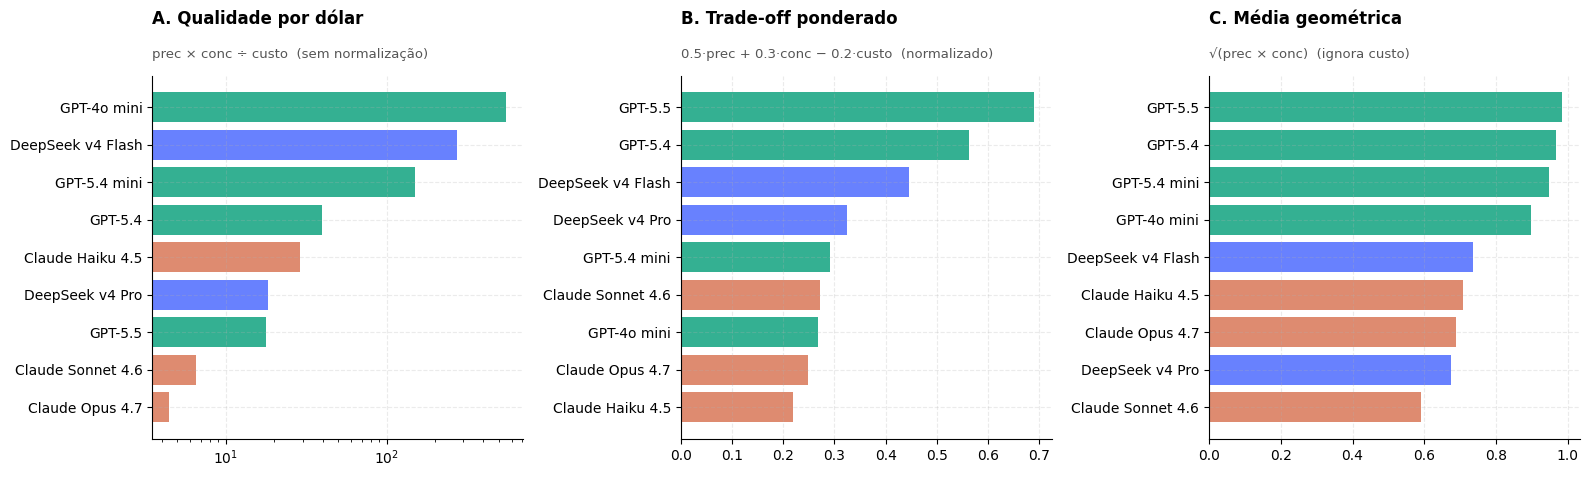

In [9]:
# Visualização lado a lado dos três rankings (cada painel com seu próprio eixo y)
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

for ax, (col, titulo, sub) in zip(axes, [
    ('A_qualidade_por_dolar',
     'A. Qualidade por dólar',
     'prec × conc ÷ custo  (sem normalização)'),
    ('B_tradeoff',
     'B. Trade-off ponderado',
     '0.5·prec + 0.3·conc − 0.2·custo  (normalizado)'),
    ('C_media_geom',
     'C. Média geométrica',
     '√(prec × conc)  (ignora custo)'),
]):
    s = alvo[col].sort_values()
    cores = [CORES_FAMILIA[FAMILIA[next(k for k,v in MODELO_DISPLAY.items() if v == m)]]
             for m in s.index]
    y = np.arange(len(s))
    ax.barh(y, s.values, color=cores, alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(s.index)
    if 'dolar' in col:
        ax.set_xscale('log')
    titulo_acima(ax, titulo, sub)

plt.tight_layout(rect=[0,0,1,0.90])
plt.show()

**Como os três rankings se comportam:**

- **A. Qualidade por dólar** premia esmagadoramente o `DeepSeek v4 Flash` — é o único modelo com custo abaixo de US$ 0,003 e precisão > 95%. Para uso de alto volume, ele é a recomendação óbvia desta variante.
- **B. Trade-off ponderado** suaviza isso e tende a colocar `GPT 5.5` ou `GPT 5.4` no topo: alta precisão, alta concisão, custo intermediário.
- **C. Média geométrica** ignora custo e ranqueia pela combinação qualidade-pura — coroa `GPT 5.5` praticamente sem disputa.

**Importante:** se você muda os pesos da Variante B (digamos 0.7/0.2/0.1), o ranking muda. Use o score apropriado à sua situação; não trate nenhum como verdade.


## 6. Decisão final — tabela de vencedores por critério

Sem reduzir tudo a um número único. Cada coluna é uma maneira legítima de fazer a escolha.


In [10]:
def top3(serie, ascendente=False):
    return serie.dropna().sort_values(ascending=ascendente).head(3).index.tolist()

criterios = {
    'Precisão pura':             top3(mestre['precisao']),
    'Concisão pura':             top3(mestre['concisao']),
    'Menor custo':               top3(mestre['custo_usd'], ascendente=True),
    'Menor latência':            top3(mestre['latencia_s'], ascendente=True),
    'Qualidade-por-dólar (A)':   top3(alvo['A_qualidade_por_dolar']),
    'Trade-off ponderado (B)':   top3(alvo['B_tradeoff']),
    'Qualidade combinada (C)':   top3(alvo['C_media_geom']),
}

decisao = pd.DataFrame(criterios, index=['1º','2º','3º']).T
decisao

,1º,2º,3º
Precisão pura,GPT-5.5,Claude Opus 4.7,Claude Sonnet 4.6
Concisão pura,ChatGPT (chat web),GPT-5.4 mini,GPT-5.4
Menor custo,GPT-4o mini,DeepSeek v4 Flash,GPT-5.4 mini
Menor latência,GPT-5.4 mini,GPT-4o mini,GPT-5.4
Qualidade-por-dólar (A),GPT-4o mini,DeepSeek v4 Flash,GPT-5.4 mini
Trade-off ponderado (B),GPT-5.5,GPT-5.4,DeepSeek v4 Flash
Qualidade combinada (C),GPT-5.5,GPT-5.4,GPT-5.4 mini


**Como ler esta tabela.** Cada linha é um critério de seleção. Quem aparece **mais vezes no topo** é o modelo mais robusto à escolha do critério.


In [11]:
todos = []
for col in decisao.columns:
    todos.extend(decisao[col].tolist())
robustez = pd.Series(todos).value_counts()
print('Quantas vezes cada modelo aparece no top-3 dos 7 critérios:')
print()
print(robustez.to_string())

Quantas vezes cada modelo aparece no top-3 dos 7 critérios:

GPT-5.4 mini          5
GPT-5.4               4
GPT-5.5               3
GPT-4o mini           3
DeepSeek v4 Flash     3
ChatGPT (chat web)    1
Claude Opus 4.7       1
Claude Sonnet 4.6     1


## 7. Fechamento

Três achados que merecem ficar na cabeça depois deste estudo:

1. **Para uso de alto volume com restrição de custo:** `DeepSeek v4 Flash`. Entrega 97% de precisão a US$ 0,002 — uma ordem de grandeza mais barato que qualquer alternativa razoável.

2. **Para uso onde precisão e concisão importam tanto quanto custo médio:** `GPT 5.5` ou `GPT 5.4`. Aparecem no top-3 da maioria dos critérios. GPT 5.5 é o único modelo a fechar próximo de 100% em precisão e 97% em concisão simultaneamente.

3. **O prêmio pago em Claude Opus 4.7 não se justifica neste domínio.** A precisão é virtualmente idêntica à de modelos 50-75× mais baratos. Faz sentido só em tarefas fora desta amostra — texto longo, raciocínio multi-etapa, contexto extenso.

Pontos abertos para um estudo futuro:
- **Concordância humano-juiz** — só temos nota humana em 121 casos (os de divergência). Um sample aleatório com avaliação humana cega permitiria estimar o viés sistemático de cada juiz LLM.
- **Robustez a perguntas adversariais** — todas as perguntas foram derivadas dos editais. Como os modelos se comportam em perguntas armadilha ou fora de escopo?
- **Custo amortizado** — o estudo usa custo por consulta; em produção com cache de input, o custo efetivo dos modelos com input grande (Claude) muda muito.
